# 04 Thinking In Langgraph
- 기획을 할때 어떻게 해야하는지
- 랭그래프 특성 어떤것이 있는지

In [6]:
from dotenv import load_dotenv
load_dotenv()

True

## Langchain의 Agent도 결국 작은 Graph다.

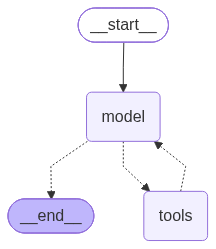

In [7]:
from langchain.agents import create_agent

# 샘플 Tool
def a():
    '''설명'''
    return 0

def b():
    '''설명'''
    return 1

# Langchain 의 Pre-built Agent
create_agent(model='openai:gpt-4.1-mini', tools=[a, b])

### Langgraph로 직접 만들기

In [19]:
# Tool
from langchain.tools import tool  # 데코레이터

@tool  # 이 함수는 단순 함수가 아닌 tool이다.
def add(a: int, b: int):
    '''
    `a` 와 `b`를 더한다.
    Args:
        a: first int
        b: second int
    '''
    return a + b


@tool
def multiply(a: int, b: int):
    '''
    `a` 와 `b`를 곱한다.
    Args:
        a: first int
        b: second int
    '''
    return a * b


@tool
def divide(a: int, b: int):
    '''
    `a` 와 `b`를 나눈다.
    Args:
        a: first int
        b: second int
    '''
    return a / b


tools = [add, multiply, divide]
tools_by_name = {tool.name: tool for tool in tools}  # dict comprehension -> for + 딕셔너리 생성 한번에!
tools_by_name

{'add': StructuredTool(name='add', description='`a` 와 `b`를 더한다.\nArgs:\n    a: first int\n    b: second int', args_schema=<class 'langchain_core.utils.pydantic.add'>, func=<function add at 0x0000018D8AE061F0>),
 'multiply': StructuredTool(name='multiply', description='`a` 와 `b`를 곱한다.\nArgs:\n    a: first int\n    b: second int', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x0000018D8AD00B40>),
 'divide': StructuredTool(name='divide', description='`a` 와 `b`를 나눈다.\nArgs:\n    a: first int\n    b: second int', args_schema=<class 'langchain_core.utils.pydantic.divide'>, func=<function divide at 0x0000018D8AD03950>)}

In [ ]:
from langchain.chat_models import init_chat_model

llm = init_chat_model('openai:gpt-4.1-mini')
llm_with_tools = llm.bind_tools(tools)

# 차이 확인
print(llm.invoke('1+1*2/4'))  # 답변(content)생성, tool_calls 비어있음
llm_with_tools.invoke('1+1*3/4')  # 답변 없음, 대신 tool_calls 항목이 있음
'''
tool_calls = [
    {'name': 'multiply', 'args': {'a': 1, 'b': 3}, 'id': 'call_Mqz8JCrZAqXEoCFVdSsQ8uuA', 'type': 'tool_call'}, 
    {'name': 'divide', 'args': {'a': 3, 'b': 4}, 'id': 'call_J4atsqL9OKkUoLM2Sy7vUriE', 'type': 'tool_call'}
]
'''
# 결론: bind_tools() 된 llm 은, 본인이 가지고 있는 tool 목록 확인 -> 계획만 짜 놓음 (tool 실행 아님)


content="Let's evaluate the expression step-by-step:\n\n1 + 1 * 2 / 4\n\nAccording to the order of operations (PEMDAS/BODMAS), we perform multiplication and division first, from left to right:\n\n1 * 2 = 2  \n2 / 4 = 0.5  \n\nNow, the expression becomes:\n\n1 + 0.5 = 1.5\n\n**Answer:** 1.5" additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 88, 'prompt_tokens': 14, 'total_tokens': 102, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_c721606bd7', 'id': 'chatcmpl-EJq110C40ra45jMDDpfhP0z1S3OHT', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--01a064c2-db94-7ce2-9b3c-dd0eef9b2c

AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 50, 'prompt_tokens': 155, 'total_tokens': 205, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_8b33040d7b', 'id': 'chatcmpl-EJq12VyJgnVxKpvtelUXvVY7PJCoX', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a064c2-e0f0-7dc2-84d1-4004fe5d5979-0', tool_calls=[{'name': 'multiply', 'args': {'a': 1, 'b': 3}, 'id': 'call_Mqz8JCrZAqXEoCFVdSsQ8uuA', 'type': 'tool_call'}, {'name': 'divide', 'args': {'a': 3, 'b': 4}, 'id': 'call_J4atsqL9OKkUoLM2Sy7vUriE', 'type': 'tool_call'}], invalid_tool_calls=[], usag

In [24]:
# 노드로 감싸서, 그래프로 조립.
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain.messages import SystemMessage, HumanMessage, AIMessage


def llm_call(state: MessagesState):
    '''LLM이 Tool 사용을 결정'''
    messages = [
        SystemMessage('너는 사칙연산을 도와주는 멋진 에이전트야.')
    ] + state['messages']

    result = llm_with_tools.invoke(messages)  # Tool 실행 계획
    return {'messages': result}


# 노드 단일 테스트
llm_call({
    'messages': [HumanMessage('1+1 계산해줘')]
})

{'messages': AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 173, 'total_tokens': 190, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_b0bb179f09', 'id': 'chatcmpl-EJqFctx9dxiSzet3L5JzWB7aTLLnf', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a064d0-aa89-7b02-ade3-f6311bbee335-0', tool_calls=[{'name': 'add', 'args': {'a': 1, 'b': 1}, 'id': 'call_YoR0KgBVSehMHaH9sFQ57FrR', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 173, 'output_tokens': 17, 'total_tokens': 190, 'input_token_details': 

## Node의 병렬 실행
